# Regressão Linear Simples

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Deixar toda a lógica do cálculo em uma célula separada e a lógica de plot do gráfico em outra célula
1. Leitura dos dados do arquivo CSV usando numpy
Ignoramos a primeira linha (skip_header=1) pois ela contem os cabeçalhos 'x, y'"5. Regressão Linear.pdf"

In [4]:
dados = np.genfromtxt('kc_house_data.csv', delimiter=',', skip_header=1, usecols=(5,2))
x = dados[:, 0] # Variavel independente: sqft_living
y = dados[:, 1] # Variavel dependente: price
n = len(x)

### 2. Cálculo dos somatórios necessários paraas fórmulas

In [5]:
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_xy = np.sum(x * y)
sum_x2 = np.sum(x**2) # **2, Faz o valor quandrado do numero
sum_y2 = np.sum(y**2)

### 3. Cálculo da Reta de Regressão (y_hat = a + b*x)

In [6]:
# Calculando o coeficiente 'b'
b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)

# Calculando o coeficiente 'a'
a = (sum_y - b * sum_x) / n

# Gerando os valores previstos (y_hat)
y_hat = a + b * x

### 4. Calculo do Coeficiente de Correlação de Pearson (r)

In [7]:
numerador_r = n * sum_xy - (sum_x * sum_y)
denominador_r = np.sqrt(n * sum_x2 - sum_x**2) * np.sqrt(n * sum_y2 - sum_y**2) #sqrt é a função de raiz quadrada. 
r = numerador_r / denominador_r

### 5. Calculo do Coeficiente de  Determinação (R²)

In [8]:
y_mean = np.mean(y) #
# Fórmula: Somatório de (y_hat - y_mean)² dividido pelo Somatório de (y - y_mean)²
sq_reg = np.sum((y_hat - y_mean)**2) 
sq_tot = np.sum((y - y_mean)**2)

r2 = sq_reg / sq_tot

### 6. Exibição dos Resultados no Console

In [9]:
print(f"Equação da reta: ŷ = {a:.4f} + {b:.4f} * x")
print(f"Coeficiente de Correlação (r): {r:.4f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

# Esses dados indicam que existe uma forte correlação entre o preço e o tamanho da casa,
#  mas que a variação de preços não é muito bem explicada somente pelo tamanho da casa.

Equação da reta: ŷ = -43580.7431 + 280.6236 * x
Coeficiente de Correlação (r): 0.7020
Coeficiente de Determinação (R²): 0.4929


### 7. Visualização Grafica dos Dados

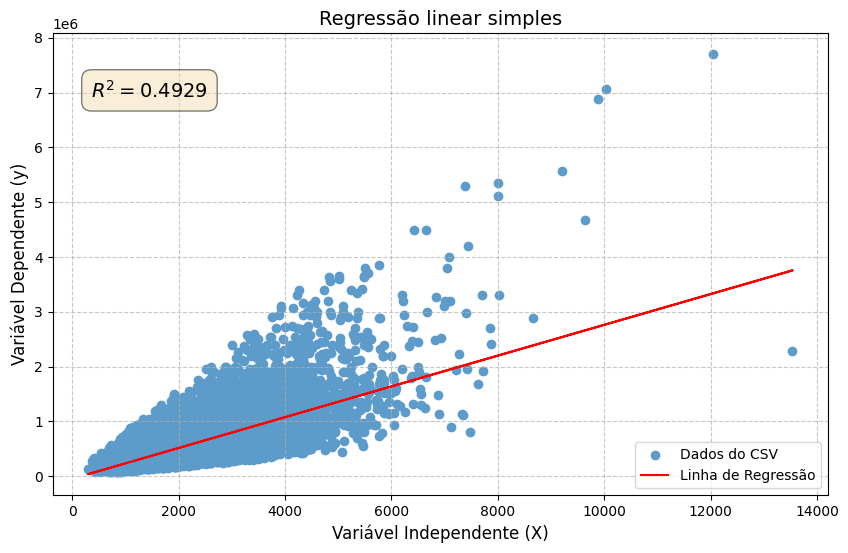

In [10]:
plt.figure(figsize=(10, 6))

# Gráfico de dispersão (scatter plot) dos dados reais
plt.scatter(x, y, color='#5D9BCA', label='Dados do CSV')

# Linha de regressão gerada pelo modelo
plt.plot(x, y_hat, color='red', label='Linha de Regressão')

# Configurações de layout do gráfico
plt.title('Regressão linear simples', fontsize=14)
plt.xlabel('Variável Independente (X)', fontsize=12)
plt.ylabel('Variável Dependente (y)', fontsize=12)

# Adiciona o valor do R² ao gráficopara fácil visualização
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes, 
         fontsize=14, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()